# Confusion Matrix

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split

In [11]:
df = pd.DataFrame({
    "Age": [36, 42, 23, 52, 43, 44, 66, 35, 52, 35, 24, 18, 45],
    "Experience": [10, 12, 4, 4, 21, 14, 3, 14, 13, 5, 3, 3, 9],
    "Rank": [9, 4, 6, 4, 8, 5, 7, 9, 7, 9, 5, 7, 9],
    "Nationality": ["UK", "USA", "N", "USA", "USA", "UK", "N", "UK", "N", "N", "USA", "UK", "UK"],
    "Go": ["NO", "NO", "NO", "NO", "YES", "NO", "YES", "YES", "YES", "YES", "NO", "YES", "YES"]
})

In [12]:
df.head()

,Age,Experience,Rank,Nationality,Go
0,36,10,9,UK,NO
1,42,12,4,USA,NO
2,23,4,6,N,NO
3,52,4,4,USA,NO
4,43,21,8,USA,YES


In [13]:
df['Nationality'] = df['Nationality'].map({
    'UK' : 0,
    'USA' : 1,
    'N' : 2
})

df['Go'] = df['Go'].map({
    'NO' : 0,   
    'YES' : 1
})

In [14]:
df.sample()

,Age,Experience,Rank,Nationality,Go
3,52,4,4,1,0


In [15]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [18]:
# Create and train Decision Tree model

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
# Predict on test data

y_pred = dt.predict(X_test)

In [21]:
# Create Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

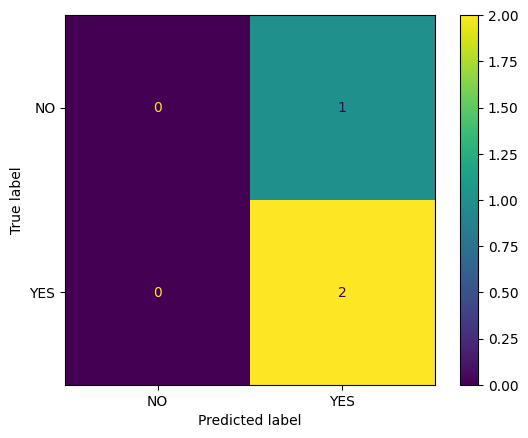

In [23]:
# Display Confusion Matrix

dis = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ['NO', 'YES']
)

dis.plot()
plt.show()

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6666666666666666


In [26]:
precision = precision_score(y_test, y_pred)
print(precision)

0.6666666666666666


In [27]:
recall = recall_score(y_test, y_pred)
print(recall)

1.0


In [30]:
f1 = f1_score(y_test, y_pred)
print(f1)

0.8
